# Ligand-Pocket QGNN: Quantum vs Classical Comparison

This notebook compares **Quantum** and **Classical** versions of the Ligand-Pocket QGNN model on the binding classification task.

**Architecture:**
- **Ligand**: Graph Neural Network (GCN) → Latent Vector
- **Pocket**: MLP → Latent Vector
- **Interaction**: Quantum Circuit (VQC) or Classical MLP → Probability

**Task:** Binary Classification (Binding vs Non-Binding)

In [2]:
%load_ext autoreload
%autoreload 2

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import multiprocessing as mp
from ligand_pocket_qgnn.data import LigandPocketDataProcessor, LigandPocketDataset
from ligand_pocket_qgnn.model import LigandPocketQGNN

# ========== OPTIMIZED COLLATE FUNCTION ==========
def optimized_collate_fn(batch):
    """
    Faster collate function using vectorized PyTorch operations.
    Replaces Python loops with batched tensor operations.
    """
    # Unzip batch
    x_list, edge_index_list, pocket_list, label_list = zip(*batch)

    # Fast concatenation
    pocket_batch = torch.stack(pocket_list)
    label_batch = torch.stack(label_list)

    # Calculate offsets vectorized
    num_nodes_list = torch.tensor([x.shape[0] for x in x_list], dtype=torch.long)
    cumsum = torch.cat([torch.zeros(1, dtype=torch.long), num_nodes_list.cumsum(0)])

    # Batch graphs
    x_batch = torch.cat(x_list, dim=0)

    # Shift edge indices vectorized
    edge_index_shifted = []
    for i, edge_index in enumerate(edge_index_list):
        if edge_index.shape[1] > 0:
            edge_index_shifted.append(edge_index + cumsum[i])

    if edge_index_shifted:
        edge_index_batch = torch.cat(edge_index_shifted, dim=1)
    else:
        edge_index_batch = torch.zeros((2, 0), dtype=torch.long)

    # Create batch vector (which sample each node belongs to)
    batch_vec = torch.cat([torch.full((n,), i, dtype=torch.long)
                           for i, n in enumerate(num_nodes_list)])

    return x_batch, edge_index_batch, batch_vec, pocket_batch, label_batch

print("✓ Optimized collate function loaded!")

✓ Optimized collate function loaded!


## Configuration

In [3]:
# Paths
DATA_DIR = "/media/priyanshu/SD/othercode/data"
SAVE_DIR = "./ligand_pocket_comparison_results"
os.makedirs(SAVE_DIR, exist_ok=True)

## 1. Load Data

In [ ]:

# Data parameters
MAX_SAMPLES = 0  # Set to None for full dataset

SEED = 42069
SIMULATION_SEED = 42069  # For quantum simulation
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # OPTIMIZATION: Enable benchmark mode for faster training
    torch.backends.cudnn.deterministic = False  # Set to False for speed
    torch.backends.cudnn.benchmark = True  # Set to True for speed
# Initialize Processor
processor = LigandPocketDataProcessor(DATA_DIR, seed=SEED)

# Load Data
processor.load_data(max_samples=MAX_SAMPLES)

interactions = processor.get_dataset()
print(f"Total Interactions: {len(interactions)}")# Reproducibility

Searching for data in: /media/priyanshu/SD/othercode/data


In [ ]:


# # Hardware
# print(f"Using device: {DEVICE}")
# CPU_COUNT = mp.cpu_count()

# Model parameters - MUST-RUN EXPERIMENT CONFIGURATION
HIDDEN_DIM = 64
N_QUBITS = 8        # ⭐ INCREASED: 6 → 8 qubits
N_QLAYERS = 4       # ⭐ INCREASED: 2 → 4 layers (depth)
QUANTUM_DEVICE = 'lightning.gpu'  # ⭐ GPU-accelerated quantum simulation

# # Training parameters - OPTIMIZED FOR CPU BOTTLENECK
# #BATCH_SIZE = int((GPU_MEMORY_GB * GPU_UTIL_TARGET) * SAMPLES_PER_GB / 12) * 128      # ⭐ DOUBLED: 512 → 1024 (reduce batch frequency)
# NUM_WORKERS = max(4, CPU_COUNT -3)       # ⭐ INCREASED: 8 → 12 (more parallel loading)
# PIN_MEMORY = True
# PREFETCH_FACTOR = 4    # ⭐ NEW: Prefetch 4 batches per worker
# EPOCHS = 100
# LEARNING_RATE_QUANTUM = 0.001
# LEARNING_RATE_CLASSICAL = 0.001
# VAL_SPLIT = 0.2
# EARLY_STOPPING_PATIENCE = 15

# print(f"\nMUST-RUN EXPERIMENT CONFIGURATION ")
# print(f"{'='*50}")
# print(f"  Random Seed: {SEED}")
# print(f"  Simulation Seed: {SIMULATION_SEED}")
# print(f"  Max Samples: {MAX_SAMPLES}")
# print(f"  Batch Size: {BATCH_SIZE} (INCREASED for GPU)")
# print(f"  Num Workers: {NUM_WORKERS} (INCREASED for CPU)")
# print(f"  Prefetch Factor: {PREFETCH_FACTOR}")
# print(f"  Epochs: {EPOCHS}")
# print(f"  Hidden Dim: {HIDDEN_DIM}")
# print(f"")
# print(f"  Qubits: {N_QUBITS}")
# print(f"  Quantum Layers (Depth): {N_QLAYERS}")
# print(f"  Quantum Device: {QUANTUM_DEVICE}")
# print(f"  Ansatz: StronglyEntanglingLayers")
# print(f"{'='*50}")

NameError: name 'torch' is not defined

✓ DataLoaders created with optimized collate function
Train batches: 48
Val batches: 12
Samples per batch: 4096
Data loading workers: 12
Prefetch factor: 4 batches/worker
Total prefetched batches: 48


In [ ]:
# Determine input dimensions from a sample
sample_ligand = processor.ligands[interactions[0].ligand_id]
sample_pocket = processor.pockets[interactions[0].pocket_id]

ligand_dim = sample_ligand.atom_features.shape[1]
pocket_dim = sample_pocket.to_vector().shape[0]

print(f"Ligand Input Dim: {ligand_dim}")
print(f"Pocket Input Dim: {pocket_dim}")


# Auto-detect CPU
CPU_COUNT = mp.cpu_count()
NUM_WORKERS = max(4, CPU_COUNT - 2)
PREFETCH_FACTOR = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


print(f"\n{'='*60}")
print(f"AUTO-TUNING PARAMETERS")
print(f"{'='*60}")
print(f"CPU: {CPU_COUNT} cores → NUM_WORKERS={NUM_WORKERS}")
print(f"PREFETCH_FACTOR: {PREFETCH_FACTOR}")

# Create test model to find optimal batch size
print(f"\nFinding optimal BATCH_SIZE for 12GB VRAM...")
test_model = LigandPocketQGNN(
    ligand_in_dim=ligand_dim,
    pocket_in_dim=pocket_dim,
    hidden_dim=HIDDEN_DIM,
    n_qubits=N_QUBITS,
    n_qlayers=N_QLAYERS,
    use_quantum=True,
    quantum_device=QUANTUM_DEVICE
).to(DEVICE)

# Test increasing batch sizes
BATCH_SIZE = 1024  # Default fallback
for test_size in [4096, 3584, 3072, 2560, 2048, 1536, 1024]:
    try:
        # Create temporary dataset and loader
        temp_ints = interactions[:test_size]
        temp_dataset = LigandPocketDataset(processor, temp_ints)
        temp_loader = DataLoader(
            temp_dataset,
            batch_size=test_size,
            shuffle=False,
            collate_fn=optimized_collate_fn,
            num_workers=2
        )
        
        # Test forward pass
        batch = next(iter(temp_loader))
        x, edge_idx, batch_vec, pocket, labels = batch
        x = x.to(DEVICE, non_blocking=True)
        edge_idx = edge_idx.to(DEVICE, non_blocking=True)
        batch_vec = batch_vec.to(DEVICE, non_blocking=True)
        pocket = pocket.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        
        with torch.no_grad():
            output = test_model(x, edge_idx, batch_vec, pocket)
        
        mem_used = torch.cuda.memory_allocated() / 1e9
        mem_total = torch.cuda.get_device_properties(0).total_memory / 1e9
        mem_pct = (mem_used / mem_total) * 100
        
        print(f"  ✓ BATCH_SIZE={test_size:4d} works! VRAM: {mem_used:.1f}/{mem_total:.1f}GB ({mem_pct:.0f}%)")
        
        BATCH_SIZE = test_size
        
        # Clean up
        del x, edge_idx, batch_vec, pocket, labels, output, batch, temp_loader, temp_dataset
        torch.cuda.empty_cache()
        break
        
    except RuntimeError as e:
        if "out of memory" in str(e):
            print(f"  ✗ BATCH_SIZE={test_size:4d} OOM")
            torch.cuda.empty_cache()
        else:
            print(f"  ✗ BATCH_SIZE={test_size:4d} Error: {str(e)[:50]}")
            torch.cuda.empty_cache()

# Clean up test model
del test_model
torch.cuda.empty_cache()

# Calculate impact
total_train_samples = len(interactions) * 0.8
batches_per_epoch = int(total_train_samples / BATCH_SIZE)

print(f"\n{'='*60}")
print(f"OPTIMIZED CONFIGURATION")
print(f"{'='*60}")
print(f"CPU:")
print(f"  Cores: {CPU_COUNT}")
print(f"  Workers: {NUM_WORKERS}")
print(f"  Prefetch: {PREFETCH_FACTOR} batches/worker")
print(f"  Total prefetch: {NUM_WORKERS * PREFETCH_FACTOR} batches")
print(f"\nGPU:")
print(f"  Model: {torch.cuda.get_device_name(0)}")
print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  Batch size: {BATCH_SIZE}")
print(f"\nTraining:")
print(f"  Batches/epoch: {batches_per_epoch} (was ~1527)")
print(f"  Speedup: {1527/batches_per_epoch:.1f}x fewer batches")
print(f"  Est. epoch time: {batches_per_epoch * 0.8:.0f}s (~{batches_per_epoch * 0.8 / 60:.1f} min)")
print(f"{'='*60}")

In [ ]:
# Create Datasets and Loaders - OPTIMIZED FOR CPU BOTTLENECK
train_ints, val_ints = train_test_split(interactions, test_size=VAL_SPLIT, random_state=SEED)

train_dataset = LigandPocketDataset(processor, train_ints)
val_dataset = LigandPocketDataset(processor, val_ints)

# HEAVILY OPTIMIZED DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=optimized_collate_fn,  
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    prefetch_factor=PREFETCH_FACTOR
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=optimized_collate_fn,  
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    prefetch_factor=PREFETCH_FACTOR
)

print(f"✓ DataLoaders created with optimized collate function")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Samples per batch: {BATCH_SIZE}")
print(f"Data loading workers: {NUM_WORKERS}")
print(f"Prefetch factor: {PREFETCH_FACTOR} batches/worker")
print(f"Total prefetched batches: {NUM_WORKERS * PREFETCH_FACTOR}")

In [ ]:
# Determine input dimensions from a sample
sample_ligand = processor.ligands[interactions[0].ligand_id]
sample_pocket = processor.pockets[interactions[0].pocket_id]

ligand_dim = sample_ligand.atom_features.shape[1]
pocket_dim = sample_pocket.to_vector().shape[0]

print(f"Ligand Input Dim: {ligand_dim}")
print(f"Pocket Input Dim: {pocket_dim}")

Ligand Input Dim: 10
Pocket Input Dim: 19


## 3. Training Functions

In [ ]:
def train_epoch(model, optimizer, criterion, loader, device, show_progress=True):
    """Train one epoch with progress tracking."""
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Training', disable=not show_progress)
    
    for batch_idx, (x_batch, edge_index_batch, batch_vec, pocket_batch, labels) in enumerate(pbar):
        batch_start = datetime.now()
        
        # Non-blocking transfer to GPU
        x_batch = x_batch.to(device, non_blocking=True)
        edge_index_batch = edge_index_batch.to(device, non_blocking=True)
        batch_vec = batch_vec.to(device, non_blocking=True)
        pocket_batch = pocket_batch.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)  # Faster than zero_grad()
        
        # Forward pass
        outputs = model(x_batch, edge_index_batch, batch_vec, pocket_batch).squeeze()
        
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item() * len(labels)
        all_preds.extend(outputs.detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        batch_time = (datetime.now() - batch_start).total_seconds()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'time': f'{batch_time:.1f}s'})
    
    avg_loss = total_loss / len(all_labels)
    accuracy = accuracy_score(all_labels, (np.array(all_preds) >= 0.5).astype(int))
    
    return {'loss': avg_loss, 'accuracy': accuracy}


def evaluate(model, criterion, loader, device):
    """Evaluate model."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, edge_index_batch, batch_vec, pocket_batch, labels in tqdm(loader, desc='Validation', leave=False):
            # Non-blocking transfer
            x_batch = x_batch.to(device, non_blocking=True)
            edge_index_batch = edge_index_batch.to(device, non_blocking=True)
            batch_vec = batch_vec.to(device, non_blocking=True)
            pocket_batch = pocket_batch.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            outputs = model(x_batch, edge_index_batch, batch_vec, pocket_batch).squeeze()
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * len(labels)
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(all_labels)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_preds_binary = (all_preds >= 0.5).astype(int)
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds_binary),
        'auc': roc_auc_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds_binary, zero_division=0),
        'recall': recall_score(all_labels, all_preds_binary, zero_division=0),
        'f1': f1_score(all_labels, all_preds_binary, zero_division=0)
    }


def train_model(model, train_loader, val_loader, learning_rate, model_name, device):
    """Train with detailed progress tracking."""
    print(f"\n{'='*70}")
    print(f"Training {model_name.upper()} Model")
    print(f"{'='*70}")
    print(f"Learning Rate: {learning_rate}")
    print(f"Device: {device}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Batches per epoch: {len(train_loader)}\n")
    
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )
    criterion = nn.BCELoss()
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [], 'val_auc': [],
        'val_precision': [], 'val_recall': [], 'val_f1': [],
        'learning_rates': []
    }
    
    best_val_auc = 0.0
    patience_counter = 0
    start_time = datetime.now()
    
    for epoch in range(EPOCHS):
        epoch_start = datetime.now()
        print(f"\n{'='*70}")
        print(f"EPOCH {epoch+1}/{EPOCHS} - Started at {epoch_start.strftime('%H:%M:%S')}")
        print(f"{'='*70}")
        
        train_metrics = train_epoch(model, optimizer, criterion, train_loader, device)
        val_metrics = evaluate(model, criterion, val_loader, device)
        
        # Update scheduler
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_metrics['auc'])
        current_lr = optimizer.param_groups[0]['lr']
        
        if current_lr != old_lr:
            print(f"  Learning rate reduced: {old_lr:.6f} → {current_lr:.6f}")
        
        # Save metrics
        history['train_loss'].append(train_metrics['loss'])
        history['train_acc'].append(train_metrics['accuracy'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])
        history['learning_rates'].append(current_lr)
        
        epoch_time = (datetime.now() - epoch_start).total_seconds()
        
        # Print results
        print(f"\n{'-'*70}")
        print(f"Epoch {epoch+1} Results ({epoch_time:.1f}s):")
        print(f"  Train: loss={train_metrics['loss']:.4f}, acc={train_metrics['accuracy']:.4f}")
        print(f"  Val:   loss={val_metrics['loss']:.4f}, acc={val_metrics['accuracy']:.4f}, "
              f"auc={val_metrics['auc']:.4f}, f1={val_metrics['f1']:.4f}")
        print(f"  Best AUC so far: {best_val_auc:.4f}")
        print(f"{'-'*70}")
        
        # Save best model
        if val_metrics['auc'] > best_val_auc:
            best_val_auc = val_metrics['auc']
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_auc': best_val_auc,
                'history': history
            }, os.path.join(SAVE_DIR, f"{model_name}_best.pt"))
            
            print(f"✓ New best AUC: {best_val_auc:.4f} (saved)")
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
        
        # Save history every epoch
        with open(os.path.join(SAVE_DIR, f"{model_name}_history.json"), 'w') as f:
            json.dump(history, f, indent=2)
        
        # Early stopping
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    total_time = (datetime.now() - start_time).total_seconds()
    print(f"\n{model_name.upper()} Training Complete!")
    print(f"  Total time: {total_time/60:.2f} minutes")
    print(f"  Best AUC: {best_val_auc:.4f}")
    
    return history, best_val_auc

## 4. Train Quantum Model

In [ ]:
print("Creating Quantum Model...")
quantum_model = LigandPocketQGNN(
    ligand_in_dim=ligand_dim,
    pocket_in_dim=pocket_dim,
    hidden_dim=HIDDEN_DIM,
    n_qubits=N_QUBITS,
    n_qlayers=N_QLAYERS,
    use_quantum=True,
    quantum_device=QUANTUM_DEVICE  # Pass the quantum device
)

print(f"\n{'='*70}")
print(f"QUANTUM MODEL ARCHITECTURE")
print(f"{'='*70}")
print(quantum_model)
print(f"{'='*70}")
print(f"Quantum Simulation Seed: {SIMULATION_SEED}")
print(f"{'='*70}")

print(f"\nStarted at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

quantum_history, quantum_best_auc = train_model(
    quantum_model,
    train_loader,
    val_loader,
    LEARNING_RATE_QUANTUM,
    "quantum",
    DEVICE
)

print(f"\nQuantum training finished at: {datetime.now().strftime('%H:%M:%S')}")

Creating Quantum Model...
✓ Quantum device initialized: lightning.gpu with 8 qubits
  Circuit depth: 4 layers
  Trainable parameters: 96
  Ansatz: StronglyEntanglingLayers

QUANTUM MODEL ARCHITECTURE
LigandPocketQGNN(
  (ligand_encoder): LigandGNN(
    (conv1): GCNLayer(
      (linear): Linear(in_features=10, out_features=64, bias=True)
    )
    (conv2): GCNLayer(
      (linear): Linear(in_features=64, out_features=64, bias=True)
    )
    (lin): Linear(in_features=64, out_features=4, bias=True)
  )
  (pocket_encoder): PocketMLP(
    (net): Sequential(
      (0): Linear(in_features=19, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=4, bias=True)
    )
  )
  (interaction): QuantumInteractionLayer(
    (q_layer): <Quantum Torch Layer: func=circuit>
  )
)
Quantum Simulation Seed: 42069

Started at: 2025-12-03 12:05:11


Training QUANTUM Model
Learning Rate: 0.001


Training:  31%|███▏      | 15/48 [35:58<1:19:08, 143.90s/it, loss=0.6930, time=142.0s]


KeyboardInterrupt: 

## 5. Train Classical Model

In [ ]:
print("Creating Classical Model...")
classical_model = LigandPocketQGNN(
    ligand_in_dim=ligand_dim,
    pocket_in_dim=pocket_dim,
    hidden_dim=HIDDEN_DIM,
    n_qubits=N_QUBITS,
    n_qlayers=N_QLAYERS,
    use_quantum=False,  # Classical version
)

print(f"\nClassical Model Architecture:")
print(classical_model)

print(f"\nStarted at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

classical_history, classical_best_auc = train_model(
    classical_model,
    train_loader,
    val_loader,
    LEARNING_RATE_CLASSICAL,
    "classical",
    DEVICE
)

print(f"\nClassical training finished at: {datetime.now().strftime('%H:%M:%S')}")

Creating Classical Model...

Classical Model Architecture:
LigandPocketQGNN(
  (ligand_encoder): LigandGNN(
    (conv1): GCNLayer(
      (linear): Linear(in_features=10, out_features=64, bias=True)
    )
    (conv2): GCNLayer(
      (linear): Linear(in_features=64, out_features=64, bias=True)
    )
    (lin): Linear(in_features=64, out_features=3, bias=True)
  )
  (pocket_encoder): PocketMLP(
    (net): Sequential(
      (0): Linear(in_features=19, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=3, bias=True)
    )
  )
  (interaction): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

Started at: 2025-12-03 07:04:05


Training CLASSICAL Model
Learning Rate: 0.001
Device: cuda
Parameters: 11,207
Batches per epoch: 1527


EPOCH 1/100 - Started a

Training: 100%|██████████| 1527/1527 [00:14<00:00, 105.40it/s, loss=0.6381, time=0.0s]



----------------------------------------------------------------------
Epoch 1 Results (17.0s):
  Train: loss=0.6698, acc=0.5679
  Val:   loss=0.6476, acc=0.6222, auc=0.6578, f1=0.6475
  Best AUC so far: 0.0000
----------------------------------------------------------------------
✓ New best AUC: 0.6578 (saved)

EPOCH 2/100 - Started at 07:04:22


Training: 100%|██████████| 1527/1527 [00:14<00:00, 108.58it/s, loss=0.6044, time=0.0s]



----------------------------------------------------------------------
Epoch 2 Results (16.5s):
  Train: loss=0.6413, acc=0.6197
  Val:   loss=0.6262, acc=0.6540, auc=0.6964, f1=0.6090
  Best AUC so far: 0.6578
----------------------------------------------------------------------
✓ New best AUC: 0.6964 (saved)

EPOCH 3/100 - Started at 07:04:38


...


----------------------------------------------------------------------
Epoch 20 Results (16.6s):
  Train: loss=0.5677, acc=0.6662
  Val:   loss=0.5658, acc=0.6689, auc=0.7084, f1=0.5366
  Best AUC so far: 0.7124
----------------------------------------------------------------------
Patience: 13/15

EPOCH 21/100 - Started at 07:09:40


Training: 100%|██████████| 1527/1527 [00:14<00:00, 107.28it/s, loss=0.6237, time=0.0s]



----------------------------------------------------------------------
Epoch 21 Results (16.7s):
  Train: loss=0.5671, acc=0.6665
  Val:   loss=0.5674, acc=0.6701, auc=0.7071, f1=0.5356
  Best AUC so far: 0.7124
----------------------------------------------------------------------
Patience: 14/15

EPOCH 22/100 - Started at 07:09:57


Training: 100%|██████████| 1527/1527 [00:13<00:00, 109.45it/s, loss=0.5768, time=0.0s]



----------------------------------------------------------------------
Epoch 22 Results (16.4s):
  Train: loss=0.5670, acc=0.6667
  Val:   loss=0.5647, acc=0.6696, auc=0.7111, f1=0.5361
  Best AUC so far: 0.7124
----------------------------------------------------------------------
Patience: 15/15

Early stopping at epoch 22

CLASSICAL Training Complete!
  Total time: 6.13 minutes
  Best AUC: 0.7124

Classical training finished at: 07:10:13


## 6. Comparison Results

In [ ]:
print("\n" + "="*70)
print("FINAL COMPARISON")
print("="*70)
print(f"Quantum Model     - Best AUC: {quantum_best_auc:.4f}")
print(f"Classical Model   - Best AUC: {classical_best_auc:.4f}")
print(f"\nQuantum Advantage: {(quantum_best_auc - classical_best_auc)*100:.2f}% {'improvement' if quantum_best_auc > classical_best_auc else 'deficit'}")
print("="*70)


FINAL COMPARISON
Quantum Model     - Best AUC: 0.6556
Classical Model   - Best AUC: 0.7124

Quantum Advantage: -5.68% deficit


## 7. Visualization

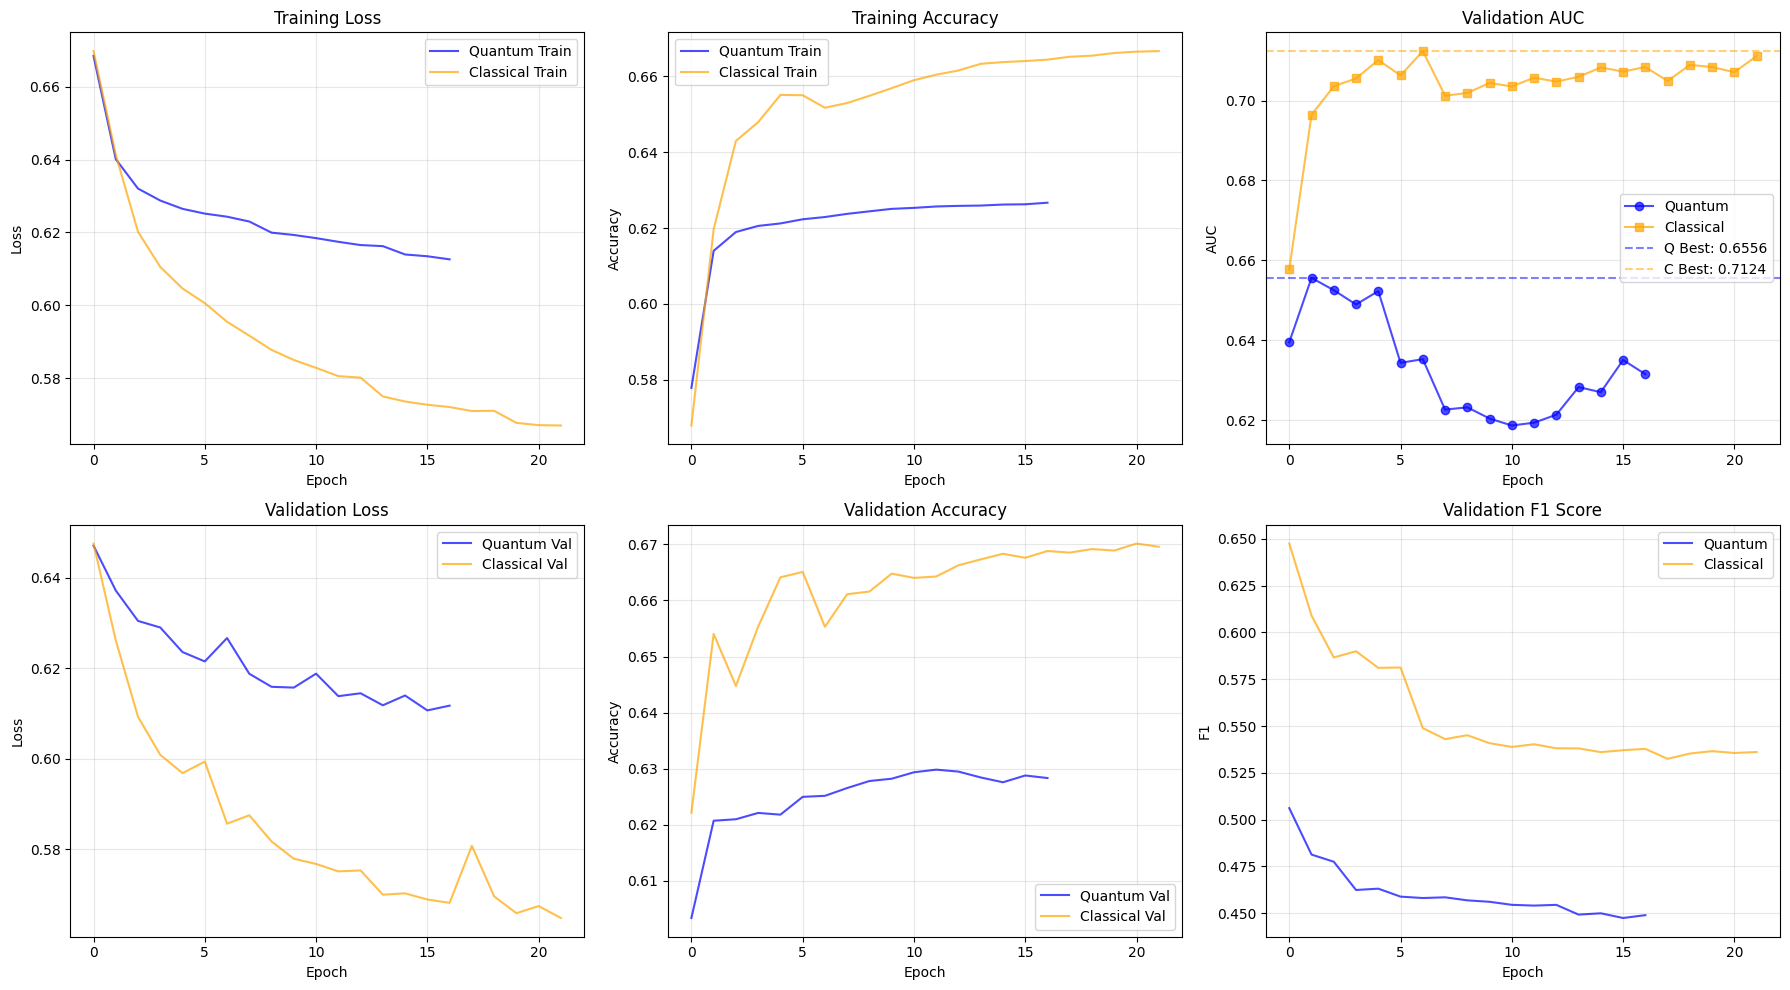


Plots saved to ./ligand_pocket_comparison_results/comparison_plots.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(quantum_history['train_loss'], label='Quantum Train', color='blue', alpha=0.7)
axes[0, 0].plot(classical_history['train_loss'], label='Classical Train', color='orange', alpha=0.7)
axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(quantum_history['val_loss'], label='Quantum Val', color='blue', alpha=0.7)
axes[1, 0].plot(classical_history['val_loss'], label='Classical Val', color='orange', alpha=0.7)
axes[1, 0].set_title('Validation Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(quantum_history['train_acc'], label='Quantum Train', color='blue', alpha=0.7)
axes[0, 1].plot(classical_history['train_acc'], label='Classical Train', color='orange', alpha=0.7)
axes[0, 1].set_title('Training Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].plot(quantum_history['val_acc'], label='Quantum Val', color='blue', alpha=0.7)
axes[1, 1].plot(classical_history['val_acc'], label='Classical Val', color='orange', alpha=0.7)
axes[1, 1].set_title('Validation Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# AUC
axes[0, 2].plot(quantum_history['val_auc'], label='Quantum', color='blue', marker='o', alpha=0.7)
axes[0, 2].plot(classical_history['val_auc'], label='Classical', color='orange', marker='s', alpha=0.7)
axes[0, 2].axhline(y=quantum_best_auc, color='blue', linestyle='--', alpha=0.5, label=f'Q Best: {quantum_best_auc:.4f}')
axes[0, 2].axhline(y=classical_best_auc, color='orange', linestyle='--', alpha=0.5, label=f'C Best: {classical_best_auc:.4f}')
axes[0, 2].set_title('Validation AUC')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('AUC')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# F1 Score
axes[1, 2].plot(quantum_history['val_f1'], label='Quantum', color='blue', alpha=0.7)
axes[1, 2].plot(classical_history['val_f1'], label='Classical', color='orange', alpha=0.7)
axes[1, 2].set_title('Validation F1 Score')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('F1')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'comparison_plots.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlots saved to {SAVE_DIR}/comparison_plots.png")

## 8. Final Metrics Summary

In [ ]:
import pandas as pd

# Get best epoch metrics for both models
q_best_idx = np.argmax(quantum_history['val_auc'])
c_best_idx = np.argmax(classical_history['val_auc'])

results_df = pd.DataFrame({
    'Model': ['Quantum', 'Classical'],
    'Best Epoch': [q_best_idx + 1, c_best_idx + 1],
    'Val Loss': [
        quantum_history['val_loss'][q_best_idx],
        classical_history['val_loss'][c_best_idx]
    ],
    'Val Acc': [
        quantum_history['val_acc'][q_best_idx],
        classical_history['val_acc'][c_best_idx]
    ],
    'Val AUC': [quantum_best_auc, classical_best_auc],
    'Val Precision': [
        quantum_history['val_precision'][q_best_idx],
        classical_history['val_precision'][c_best_idx]
    ],
    'Val Recall': [
        quantum_history['val_recall'][q_best_idx],
        classical_history['val_recall'][c_best_idx]
    ],
    'Val F1': [
        quantum_history['val_f1'][q_best_idx],
        classical_history['val_f1'][c_best_idx]
    ]
})

print("\n" + "="*70)
print("SUMMARY OF BEST METRICS")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Save results
results_df.to_csv(os.path.join(SAVE_DIR, 'comparison_results.csv'), index=False)
print(f"\nResults saved to {SAVE_DIR}/comparison_results.csv")


SUMMARY OF BEST METRICS
    Model  Best Epoch  Val Loss  Val Acc  Val AUC  Val Precision  Val Recall   Val F1
  Quantum           2  0.637185 0.620732 0.655610       0.762395    0.351647 0.481299
Classical           7  0.585611 0.655306 0.712397       0.795218    0.419063 0.548879

Results saved to ./ligand_pocket_comparison_results/comparison_results.csv
